All right. So Chris wants me to plot the SED of each of the three sodium D white dwarfs to be able to check for IR excess for a disk, which means I need to also plot detection limits or whatever.

So I downloaded the photometric points that are returned by http://cdsportal.u-strasbg.fr/?target=251.0712541%09-4.83011568

all_avg
/Users/BenKaiser/Desktop/Goodman_ref_files/line_lists/alkali_lines_vac.csv
wavelengths.min:  5891.583264
new_wavelengths.min(): 5889.95086677
wavelengths.min:  5897.558147
new_wavelengths.min(): 5895.92414977
wavelengths.min:  6709.61
new_wavelengths.min(): 6707.75804363
wavelengths.min:  6709.76
new_wavelengths.min(): 6707.90800329
wavelengths.min:  7667.008906
new_wavelengths.min(): 7664.899016
wavelengths.min:  7701.083536
new_wavelengths.min(): 7698.96445153
wavelengths.min:  8185.5054
new_wavelengths.min(): 8183.25551561
wavelengths.min:  8197.0434
new_wavelengths.min(): 8194.79039837
wavelengths.min:  8197.0766
new_wavelengths.min(): 8194.8235894


/Users/BenKaiser/.virtualenvs/stars/lib/python2.7/site-packages/matplotlib/axes/_axes.py:545: UserWarning: No labelled objects found. Use label='...' kwarg on individual plots.
  warnings.warn("No labelled objects found. "


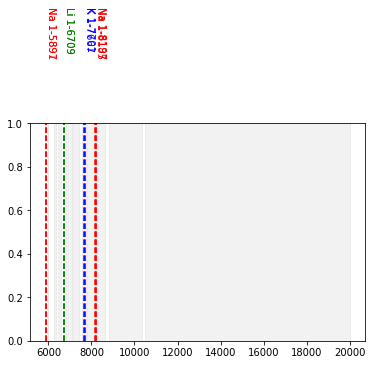

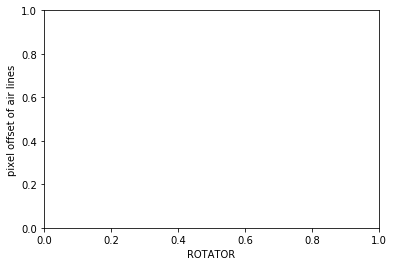

/Users/BenKaiser/Desktop/radial_velocity_calculations


In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
print(os.getcwd())

In [2]:
target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/photometry/'
os.chdir(target_dir)

In [3]:
J1644_phot_file=''
J1330_phot_file='J1330_photometry.vot'
J2356_phot_file=''

In [113]:
J1330_table=Table.read(J1330_phot_file)

In [115]:
J1330_waves=J1330_table['sed_freq'].to(u.micron, equivalencies=u.spectral())

In [117]:
J1330_table.add_column(Column(J1330_waves, name=('sed_wave')))

In [119]:
J1330_table.filled(5e-5)

_RAJ2000,_DEJ2000,_tabname,_ID,sed_freq,sed_flux,sed_eflux,sed_filter,sed_wave
deg,deg,,,GHz,Jy,Jy,,micron
float64,float64,str32,str64,float64,float32,float32,str32,float64
202.505678000,64.589984000,I/305/out,"GSC2.3===N4NM008968&-c=202.505678 +64.589984,eq=J2000&-c.rs=0.00",640580,5.61e-06,3.3e-06,POSS-II:J,0.468001589185
202.504871080,64.589914025,I/345/gaia2,"-c=202.50373929599 +64.58981955997,eq=ICRS&-c.rs=0.004",388100,3.15e-05,2.1e-06,GAIA/GAIA2:Grp,0.772461886112
202.504871080,64.589914025,I/345/gaia2,"-c=202.50373929599 +64.58981955997,eq=ICRS&-c.rs=0.004",481500,1.64e-05,2e-07,GAIA/GAIA2:G,0.62262192731
202.504871080,64.589914025,I/345/gaia2,"-c=202.50373929599 +64.58981955997,eq=ICRS&-c.rs=0.004",594100,1.43e-05,2.8e-06,GAIA/GAIA2:Gbp,0.504616155529
202.502683500,64.589127800,II/328/allwise,"AllWISE===J133000.64+643520.8&-c=202.5026835 +64.5891278,eq=J200",13571,0.00187,5e-05,WISE:W4,22.0906681895
202.502683500,64.589127800,II/328/allwise,"AllWISE===J133000.64+643520.8&-c=202.5026835 +64.5891278,eq=J200",25934,0.000172,5e-05,WISE:W3,11.5598233207
202.502683500,64.589127800,II/328/allwise,"AllWISE===J133000.64+643520.8&-c=202.5026835 +64.5891278,eq=J200",65172,2.38e-05,5e-05,WISE:W2,4.60001930277
202.502683500,64.589127800,II/328/allwise,"AllWISE===J133000.64+643520.8&-c=202.5026835 +64.5891278,eq=J200",89490,2.09e-05,3.3e-06,WISE:W1,3.35001070511


In [118]:
J1330_table.write('J1330_photometry.csv')

In [5]:
J1330_table.pprint()

   _RAJ2000      _DEJ2000   ... sed_eflux    sed_filter   
     deg           deg      ...     Jy                    
------------- ------------- ... --------- ----------------
202.505678000  64.589984000 ...   3.3e-06        POSS-II:J
202.504871080  64.589914025 ...   2.1e-06   GAIA/GAIA2:Grp
202.504871080  64.589914025 ...     2e-07     GAIA/GAIA2:G
202.504871080  64.589914025 ...   2.8e-06   GAIA/GAIA2:Gbp
202.502683500  64.589127800 ...        --          WISE:W4
202.502683500  64.589127800 ...        --          WISE:W3
202.502683500  64.589127800 ...        --          WISE:W2
202.502683500  64.589127800 ...   3.3e-06          WISE:W1
202.503887400  64.589830600 ...   2.8e-06 PAN-STARRS/PS1:y
202.503887400  64.589830600 ...   1.1e-06 PAN-STARRS/PS1:z
          ...           ... ...       ...              ...
202.504720000  64.589928000 ...     4e-06           SDSS:z
202.504720000  64.589928000 ...   1.1e-06           SDSS:i
202.504720000  64.589928000 ...     6e-07           SDSS

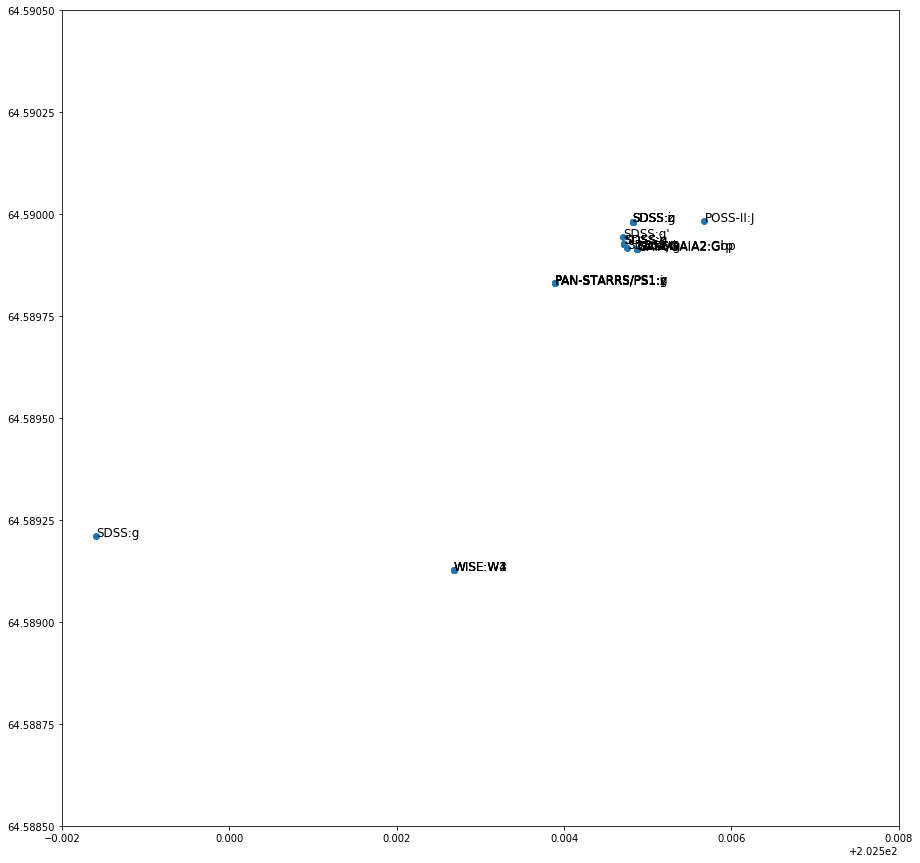

In [12]:
plt.figure(figsize=(15,15))
plt.scatter(J1330_table['_RAJ2000'], J1330_table['_DEJ2000'])
for row in J1330_table:
    plt.annotate(str(row['sed_filter']),xy=(row['_RAJ2000'], row['_DEJ2000']), xycoords='data', xytext=(row['_RAJ2000'], row['_DEJ2000']), textcoords= 'data' , fontsize=12)

plt.xlim(202.498,202.508)
plt.ylim(64.5885, 64.5905)
plt.show()

In [14]:
J1330_table.show_in_notebook()

idx,_RAJ2000,_DEJ2000,_tabname,_ID,sed_freq,sed_flux,sed_eflux,sed_filter
,deg,deg,,,GHz,Jy,Jy,
0,202.505678000,64.589984000,I/305/out,"GSC2.3===N4NM008968&-c=202.505678 +64.589984,eq=J2000&-c.rs=0.00",640580,5.61e-06,3.3e-06,POSS-II:J
1,202.504871080,64.589914025,I/345/gaia2,"-c=202.50373929599 +64.58981955997,eq=ICRS&-c.rs=0.004",388100,3.15e-05,2.1e-06,GAIA/GAIA2:Grp
2,202.504871080,64.589914025,I/345/gaia2,"-c=202.50373929599 +64.58981955997,eq=ICRS&-c.rs=0.004",481500,1.64e-05,2e-07,GAIA/GAIA2:G
3,202.504871080,64.589914025,I/345/gaia2,"-c=202.50373929599 +64.58981955997,eq=ICRS&-c.rs=0.004",594100,1.43e-05,2.8e-06,GAIA/GAIA2:Gbp
4,202.502683500,64.589127800,II/328/allwise,"AllWISE===J133000.64+643520.8&-c=202.5026835 +64.5891278,eq=J200",13571,0.00187,--,WISE:W4
5,202.502683500,64.589127800,II/328/allwise,"AllWISE===J133000.64+643520.8&-c=202.5026835 +64.5891278,eq=J200",25934,0.000172,--,WISE:W3
6,202.502683500,64.589127800,II/328/allwise,"AllWISE===J133000.64+643520.8&-c=202.5026835 +64.5891278,eq=J200",65172,2.38e-05,--,WISE:W2
7,202.502683500,64.589127800,II/328/allwise,"AllWISE===J133000.64+643520.8&-c=202.5026835 +64.5891278,eq=J200",89490,2.09e-05,3.3e-06,WISE:W1
8,202.503887400,64.589830600,II/349/ps1,"-c=202.503887400 +64.589830600,eq=J2000&-c.rs=0.004",312400,4.36e-05,2.8e-06,PAN-STARRS/PS1:y


In [15]:
J1330_waves=J1330_table['sed_freq'].to(u.micron, equivalencies=u.spectral())

In [108]:
J1330_table=J1330_table.filled(5e-5)

trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying
trying


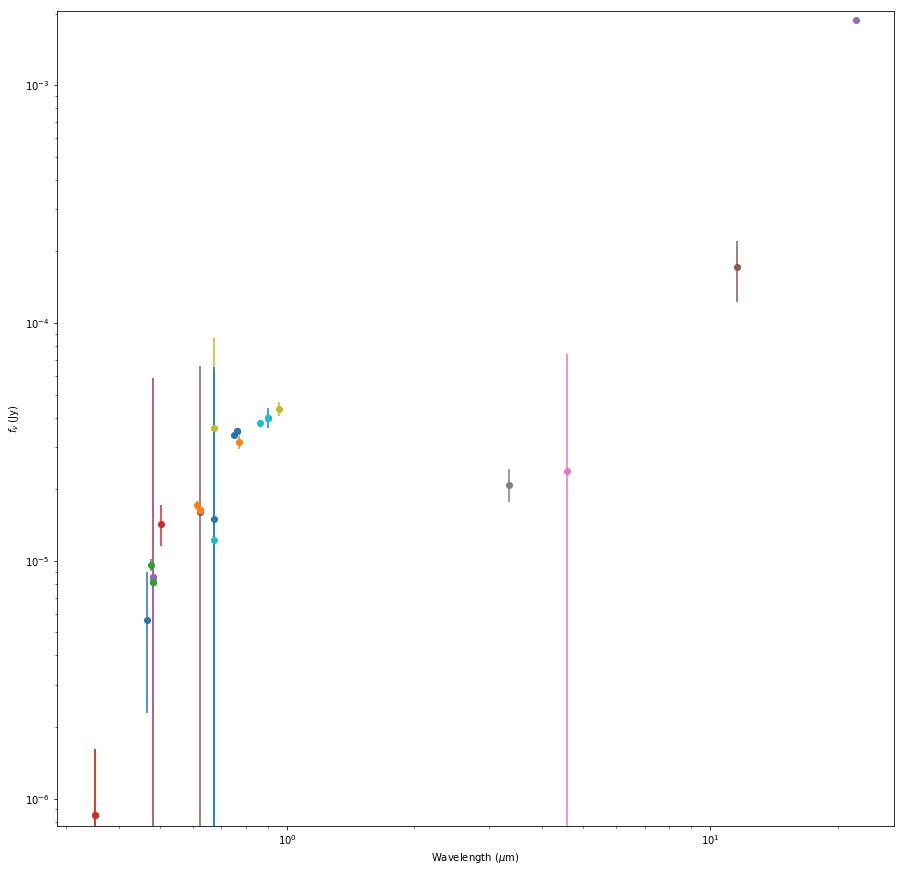

In [111]:
plt.figure(figsize=(15,15))
measured=np.where(J1330_table['sed_eflux']!= False)
limits= np.where(J1330_table['sed_eflux']== False)
for wave, row in zip(J1330_waves, J1330_table):
    #plt.scatter(wave, row['sed_flux'], marker='o', color='b')
    try:
        print('trying')
        if row['sed_eflux'].mask==True:
            print('masked')
            print(type(row['sed_eflux']).filled())
            plt.errorbar(wave.value, row['sed_flux'].quantity.value, yerr=row['sed_eflux'].quantity.value, marker='o',uplims=True)
            #print(row['sed_eflux'].filled(5).quantity.value)
    except AttributeError:
        pass
    #else:
        plt.errorbar(wave.value, row['sed_flux'], yerr=row['sed_eflux'], linestyle='none', marker='o')


#    try:
#        plt.errorbar(wave, row['sed_flux'],yerr=row['sed_eflux'], linestyle='none', marker='o', color='b')
#    except ValueError:
#        plt.errorbar(wave, row['sed_flux'], linestyle='none', marker='o')
#plt.errorbar(J1330_waves, J1330_table['sed_flux'],yerr=J1330_table['sed_eflux'], linestyle='none', marker='o')
#plt.errorbar(J1330_waves, J1330_table['sed_flux'], yerr=J1330_table['sed_eflux'],linestyle='none', marker='o', color='r')
#plt.scatter(J1330_waves, J1330_table['sed_flux'], marker='s', color='b')
#plt.errorbar(J1330_waves.value, J1330_table['sed_flux'].quantity.value, yerr=J1330_table['sed_eflux'].filled(0).quantity.value, linestyle='none', marker='o',solid_capstyle='projecting')
plt.xscale('log')
plt.ylim(np.min(J1330_table['sed_flux'])*0.9, np.max(J1330_table['sed_flux'])*1.1)
plt.yscale('log')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel(r'$f_{\nu}$ (Jy)')
plt.show()

In [25]:
print(J1330_table['sed_eflux'])

sed_eflux
    Jy   
---------
  3.3e-06
  2.1e-06
    2e-07
  2.8e-06
       --
       --
       --
  3.3e-06
  2.8e-06
  1.1e-06
      ...
    4e-06
  1.1e-06
    6e-07
  4.4e-07
  7.6e-07
    4e-06
  1.1e-06
    6e-07
  4.4e-07
  7.6e-07
Length = 34 rows


In [40]:
print(np.where(J1330_table['sed_eflux']==False))

(array([ 4,  5,  6, 13, 14, 15, 18, 19, 20]),)


In [51]:
J1330_table['sed_eflux'][measured]

3.3e-06
2.1e-06
2e-07
2.8e-06
3.3e-06
2.8e-06
1.1e-06
8e-07
7e-07
5.8e-07
4e-06


In [59]:
J1330_waves

<Quantity [  0.46800159,  0.77246189,  0.62262193,  0.50461616,
            22.09066819, 11.55982332,  4.6000193 ,  3.35001071,
             0.95964295,  0.8652019 ,  0.74798517,  0.61257143,
             0.47722454,  0.48199694,  0.48199694,  0.62469777,
             0.90179418,  0.76349121,  0.67299524,  0.67299524,
             0.67299524,  0.62469777,  0.48199694,  0.35190212,
             0.90179418,  0.76349121,  0.62469777,  0.48199694,
             0.35190212,  0.90179418,  0.76349121,  0.62469777,
             0.48199694,  0.35190212] micron>

In [65]:
J1330_table['sed_eflux'].filled(0).quantity.value

array([  3.31999991e-06,   2.10000007e-06,   2.00000002e-07,
         2.79999995e-06,   0.00000000e+00,   0.00000000e+00,
         0.00000000e+00,   3.29999989e-06,   2.79999995e-06,
         1.09999996e-06,   8.00000009e-07,   6.99999987e-07,
         5.80000005e-07,   0.00000000e+00,   0.00000000e+00,
         0.00000000e+00,   3.99999999e-06,   1.09999996e-06,
         0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
         6.00000021e-07,   4.40000008e-07,   7.62000013e-07,
         3.99999999e-06,   1.09999996e-06,   6.00000021e-07,
         4.40000008e-07,   7.62000013e-07,   3.99999999e-06,
         1.09999996e-06,   6.00000021e-07,   4.40000008e-07,
         7.62000013e-07], dtype=float32)

In [69]:
J1330_table['sed_eflux'].quantity.value

array([  3.31999991e-06,   2.10000007e-06,   2.00000002e-07,
         2.79999995e-06,              nan,              nan,
                    nan,   3.29999989e-06,   2.79999995e-06,
         1.09999996e-06,   8.00000009e-07,   6.99999987e-07,
         5.80000005e-07,              nan,              nan,
                    nan,   3.99999999e-06,   1.09999996e-06,
                    nan,              nan,              nan,
         6.00000021e-07,   4.40000008e-07,   7.62000013e-07,
         3.99999999e-06,   1.09999996e-06,   6.00000021e-07,
         4.40000008e-07,   7.62000013e-07,   3.99999999e-06,
         1.09999996e-06,   6.00000021e-07,   4.40000008e-07,
         7.62000013e-07], dtype=float32)

In [72]:
J1330_table['sed_eflux'].filled(0).quantity.value

array([  3.31999991e-06,   2.10000007e-06,   2.00000002e-07,
         2.79999995e-06,   0.00000000e+00,   0.00000000e+00,
         0.00000000e+00,   3.29999989e-06,   2.79999995e-06,
         1.09999996e-06,   8.00000009e-07,   6.99999987e-07,
         5.80000005e-07,   0.00000000e+00,   0.00000000e+00,
         0.00000000e+00,   3.99999999e-06,   1.09999996e-06,
         0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
         6.00000021e-07,   4.40000008e-07,   7.62000013e-07,
         3.99999999e-06,   1.09999996e-06,   6.00000021e-07,
         4.40000008e-07,   7.62000013e-07,   3.99999999e-06,
         1.09999996e-06,   6.00000021e-07,   4.40000008e-07,
         7.62000013e-07], dtype=float32)

In [73]:
J1330_table['sed_flux'].quantity.value

array([  5.60999979e-06,   3.14999997e-05,   1.63999994e-05,
         1.42999997e-05,   1.87000004e-03,   1.72000000e-04,
         2.37999993e-05,   2.09000009e-05,   4.36000009e-05,
         3.79999983e-05,   3.36999983e-05,   1.72000000e-05,
         9.63000002e-06,   8.57000032e-06,   8.58000021e-06,
         1.61000007e-05,   3.99999990e-05,   3.51000017e-05,
         3.61999992e-05,   1.22000001e-05,   1.49999996e-05,
         1.63000004e-05,   8.16000011e-06,   8.52000028e-07,
         3.99999990e-05,   3.51000017e-05,   1.63000004e-05,
         8.16000011e-06,   8.52000028e-07,   3.99999990e-05,
         3.51000017e-05,   1.63000004e-05,   8.16000011e-06,
         8.52000028e-07], dtype=float32)